# Time Series with Prophet Model

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

In [8]:
df = pd.read_csv("data/Index2018.csv")
df.head()

,date,spx,dax,ftse,nikkei
0,07/01/1994,469.90,2224.95,3445.98,18124.01
1,10/01/1994,475.27,2225.00,3440.58,18443.44
2,11/01/1994,474.13,2228.10,3413.77,18485.25
3,12/01/1994,474.17,2182.06,3372.02,18793.88
4,13/01/1994,472.47,2142.37,3360.01,18577.26


**The data:** daily closing prices for four major stock indices, starting in January 1994. We'll build a Prophet model for the S&P 500 (`spx`).

## Data Preprocessing

In [9]:
#convert date column to datetime
#error='coerce' will turn invalid parsing into NaT
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

In [10]:
# rename columns, drop NaNs, and sort by date
df = df[['date','spx']].rename(columns={'date':'ds','spx':'y'}).dropna().sort_values('ds')

In [12]:
# ensure 'y' is numeric, coerce errors to NaN
df['y'] = pd.to_numeric(df['y'], errors='coerce')

In [13]:
# drop rows where 'y' is NaN and reset index
df = df.dropna(subset=['y']).reset_index(drop=True)

In [14]:
df.head()

,ds,y
0,1994-01-07,469.90
1,1994-01-10,475.27
2,1994-01-11,474.13
3,1994-01-12,474.17
4,1994-01-13,472.47


**Ready for Prophet:** the date column is now a proper datetime and the data is cleaned, sorted, and limited to the S&P 500. Prophet needs exactly two columns — `ds` for dates and `y` for the values.

## Train/Test Split

In [15]:
# 80:20 split
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train rows: 5015, Test rows: 1254


**The split:** data is split chronologically — 80% for training (5,015 rows) and 20% for testing (1,254 rows). Splitting by date simulates predicting the future, since Prophet never sees the test period when fitting.

In [16]:
#Fit Prophet
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
model.fit(train)

10:25:27 - cmdstanpy - INFO - Chain [1] start processing
10:25:29 - cmdstanpy - INFO - Chain [1] done processing


**The model:** Prophet is fit with yearly and weekly seasonality, which suits daily trading data. Weekly seasonality captures weekday effects; yearly captures repeating calendar patterns.

## Make Predictions

In [17]:
# Create future dataframe for the entire period (train + test)
future = pd.DataFrame({'ds': pd.date_range(start=df['ds'].min(),
                                           end=df['ds'].max(),
                                           freq='B')})  # B = business days

forecast = model.predict(future)

In [18]:
# Merge predictions with test set
merged = pd.merge(
    test[['ds','y']].rename(columns={'y':'y_true'}),
    forecast[['ds','yhat','yhat_lower','yhat_upper']],
    on='ds',
    how='left'
).set_index('ds')

**Forecasting:** Prophet predicts the whole period on business days (matching the trading calendar), then predictions are matched up with the real test values for comparison. Each forecast `yhat` comes with a lower and upper bound.

In [19]:
# Evaluate
mae  = mean_absolute_error(merged['y_true'], merged['yhat'])
rmse = math.sqrt(mean_squared_error(merged['y_true'], merged['yhat']))
mape = np.mean(np.abs((merged['y_true'] - merged['yhat']) / merged['y_true'])) * 100

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 224.04
RMSE: 249.46
MAPE: 10.48%


**How good is it?** On the held-out test set, predictions miss the real value by about 224 points on average (MAE). The MAPE of ~10.5% means the forecast is usually about one tenth off. RMSE (249) is higher than MAE, so larger errors are dragging the average up.

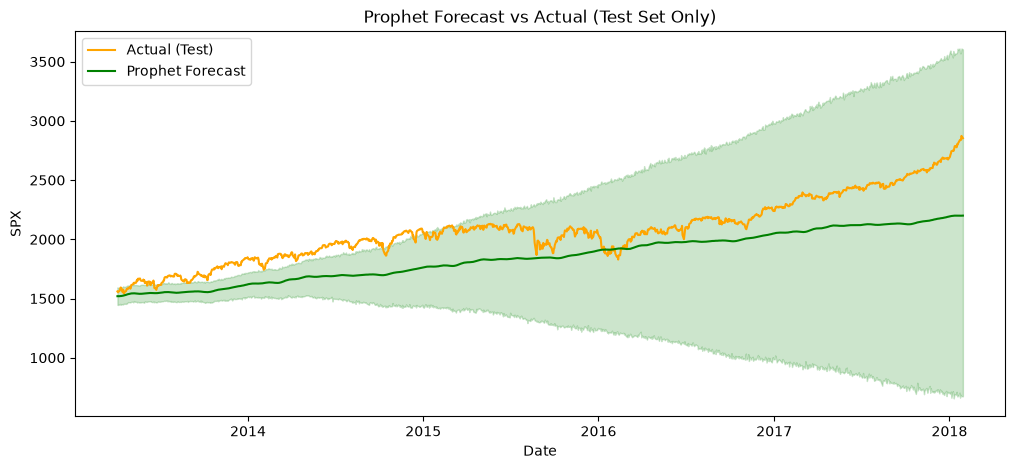

In [20]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(merged.index, merged['y_true'], label='Actual (Test)', color='orange')
plt.plot(merged.index, merged['yhat'], label='Prophet Forecast', color='green')
plt.fill_between(merged.index, merged['yhat_lower'], merged['yhat_upper'],
                 color='green', alpha=0.2)
plt.title('Prophet Forecast vs Actual (Test Set Only)')
plt.xlabel('Date')
plt.ylabel('SPX')
plt.legend()
plt.show()

**The plot:** the green forecast line tracks the orange actual values reasonably well over the test period, and the shaded band shows the model's uncertainty around each prediction.

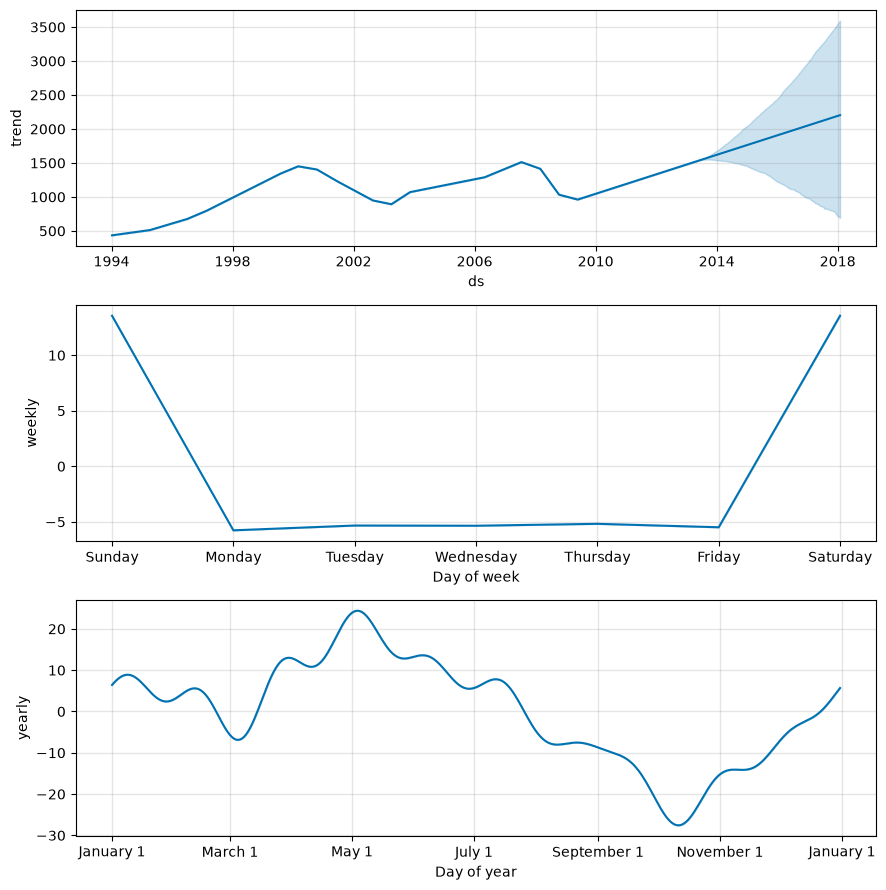

In [21]:
# Prophet component plots
model.plot_components(forecast)
plt.show()

**What drives the forecast:** Prophet breaks the prediction into parts — a long-term trend, a yearly seasonal pattern, and a weekly pattern. This shows how much of the movement comes from the overall trend versus recurring calendar effects.